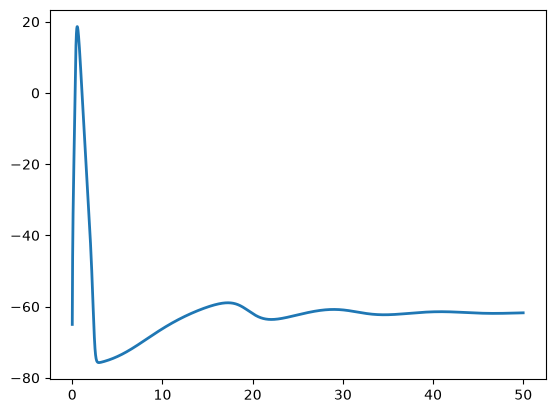

In [1]:

from aufgabe2.ode_solver_euler import euler_method
import matplotlib.pyplot as plt
import numpy as np

x = np.array([-65,0.6, 0.5, 0.4])
tuple_of_constants = (1, 36, 120, 0.3, -77, 50, -54.387)

t_a = 0
t_b = 50
dt = 0.01

I_0 = 5
I = lambda t: I_0
v = euler_method(x, t_a, t_b, dt, I, tuple_of_constants) [0: ,0]
tpoints = np.arange(0, 50, dt)
plt.plot(tpoints,v, linewidth=2)

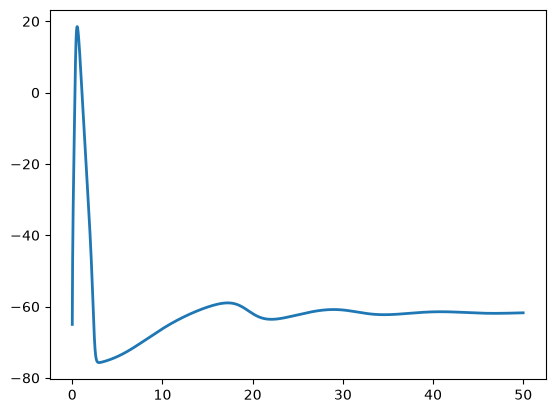

In [2]:
from aufgabe2.ode_solver_runge_kutta import runge_kutta_method


v = runge_kutta_method(x, t_a, t_b, dt, I, tuple_of_constants) [0: ,0]
plt.plot(tpoints,v, linewidth=2)

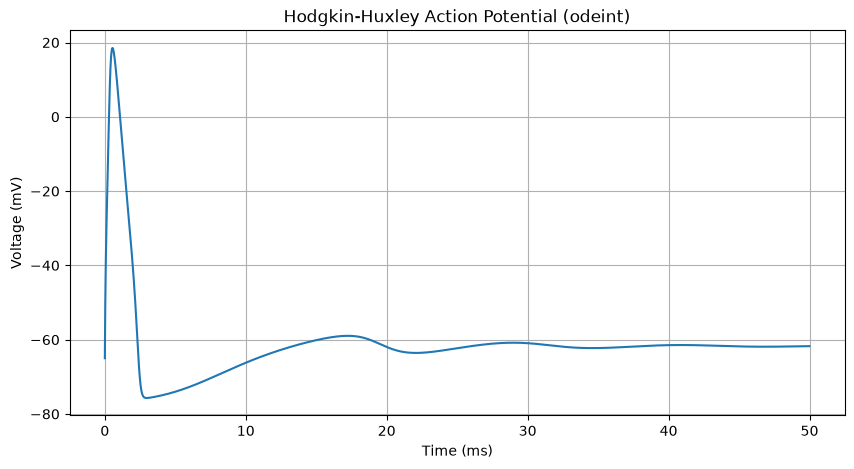

In [3]:
import scipy.integrate as spi
import aufgabe2.equations as eq
state_0 = [-65, 0.6, 0.5, 0.4]

# --- Time array and injected current ---
   # 0 to 50 ms, fine resolution
I = 5                        # constant injected current [uA/cm^2]

# --- Solve ---


def hh_system(state, t, I, tuple_of_constants : tuple[float]):
    return eq.equations_vector(state, I, tuple_of_constants)

solution = spi.odeint(hh_system, state_0, tpoints, args=(I,tuple_of_constants) )

V_t = solution[:, 0]


# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(tpoints, V_t)
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title('Hodgkin-Huxley Action Potential (odeint)')
plt.grid(True)
plt.show()

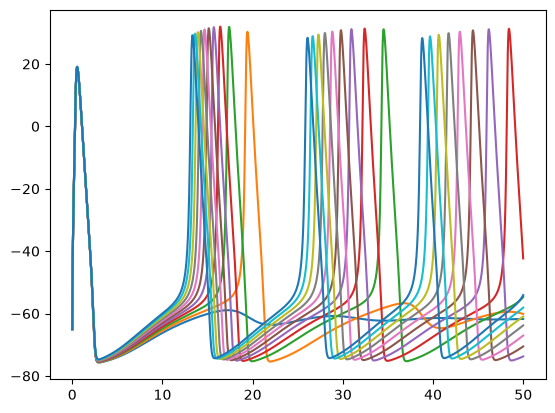

In [8]:
current_values = [(lambda t, val=val: val) for val in range(5, 16)]
list_of_arrays = []
for i in current_values:
    temp = euler_method(x, t_a, t_b, dt, i, tuple_of_constants) [0: ,0]
    list_of_arrays.append(temp)

voltage_matrix = np.array(list_of_arrays)
plt.plot(tpoints, voltage_matrix.T)
plt.show()


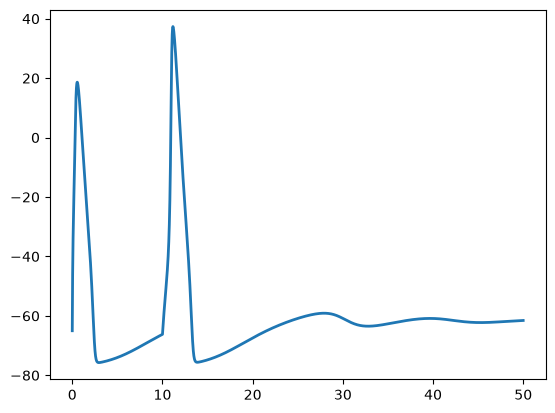

In [9]:
I = lambda t: 50 if (10 <= t <= 11) else I_0
v = euler_method(x, t_a, t_b, dt, I, tuple_of_constants) [0: ,0]
tpoints = np.arange(0, 50, dt)
plt.plot(tpoints,v, linewidth=2)
